# DATA LOADING

In [1]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pymde
import torch

In [3]:
import idx2numpy

def load_and_reshape_idx(file_path, is_image=True):
    """
    Load and reshape IDX file data.

    Parameters:
    file_path (str): Path to the IDX file.
    is_image (bool): Whether the file contains image data. If True, the data will be reshaped.

    Returns:
    np.ndarray: Loaded and optionally reshaped data.
    """
    # Load the data using idx2numpy
    data = idx2numpy.convert_from_file(file_path)
    
    # Reshape the data if it is image data
    if is_image:
        num_images, rows, cols = data.shape
        data = data.reshape(num_images, rows * cols)
    
    return data

# Load the training data
train_images = load_and_reshape_idx("data/train-images-idx3-ubyte", is_image=True)
train_labels = load_and_reshape_idx("data/train-labels-idx1-ubyte", is_image=False)

# Load the test data
test_images = load_and_reshape_idx("data/t10k-images-idx3-ubyte", is_image=True)
test_labels = load_and_reshape_idx("data/t10k-labels-idx1-ubyte", is_image=False)

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


# PREPROCESSING

In [4]:
print("len(train_images):", len(train_images))
print("len(train_labels):", len(train_labels))

len(train_images): 60000
len(train_labels): 60000


In [5]:
# Split training data into training and validation sets (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

print("Training set size:", len(train_images))
print("Validation set size:", len(val_images))

Training set size: 48000
Validation set size: 12000


In [6]:
# Normalize the image data
scaler = MinMaxScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)

In [7]:
train_images_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
# Drop and Rotation if possible and necessary...
# Define data augmentation
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28)
])

# **Visualization using PyMDE**

### **What is PyMDE?**
PyMDE (Minimum Distortion Embedding) is a tool for dimensionality reduction that aims to create low-dimensional embeddings of high-dimensional data while preserving the structure and relationships within the data. It minimizes distortion to maintain the integrity of the original data relationships.

### **Why Use PyMDE with Constraints on Fashion MNIST?**
1. **Standardization**:
- **Zero Mean**: Ensures that the center of the embedding is at zero, making the data balanced around the origin.
- **Unit Variance**: Ensures that the spread of the data is consistent, with an average distance of one unit from the center.

2. **Improved Interpretability**:
- **Consistent Scaling**: By standardizing the embedding, the data points are on a consistent scale, making it easier to compare and interpret the relationships between different classes.
- **Balanced Data**: A zero mean ensures that the data is centered, making the visualization more balanced and easier to understand.

3. **Preserve Data Structure**:
- **Minimize Distortion**: PyMDE aims to preserve the local and global structure of the data, ensuring that similar items remain close to each other in the embedding.
- **Maintain Relationships**: Constraints help maintain the important relationships and structures within the data during the dimensionality reduction process.

### **Choosing the Right Constraint for the Fashion MNIST Dataset**
When working with the Fashion MNIST dataset, the choice of constraint can significantly impact the quality and interpretability of the resulting embeddings. Here are some common constraints and recommendations on which to apply:

1. **Standardized Constraint**
- **Description**: Ensures that the embedding has zero mean and unit variance.
- **Use Cas**e: Ideal for datasets where you want the embedding to be on a standardized scale, making it easier to compare and interpret.
- **Benefits**:
  - **Consistent Scaling**: Ensures that the data points are on a consistent scale.
  - **Balanced Data**: Centers the data around the origin, making the visualization more balanced.
- **Example**:

Oct 26 03:36:18 PM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 870863 edges.
Oct 26 03:36:18 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:36:18 PM: iteration 000 | distortion 0.215975 | residual norm 0.023497 | step length 0.566254 | percent change 0.00429426
Oct 26 03:36:21 PM: iteration 030 | distortion 0.136296 | residual norm 0.000356364 | step length 1 | percent change 0.647524
Oct 26 03:36:23 PM: iteration 060 | distortion 0.133559 | residual norm 9.0703e-05 | step length 1 | percent change 0.396037
Oct 26 03:36:26 PM: iteration 090 | distortion 0.133225 | residual norm 6.28238e-05 | step length 1 | percent change 0.430625
Oct 26 03:36:29 PM: iteration 120 | distortion 0.132961 | residual norm 5.31708e-05 | step length 1 | percent change 0.29754
Oct 26 03:36:31 PM: iteration 150 | distortion 0.132779 | residual norm 5.88954e-05 | step length 1 | percent change 0.370026
Oct 26 03:36:34 PM: iteration 180 | disto

<Axes: >

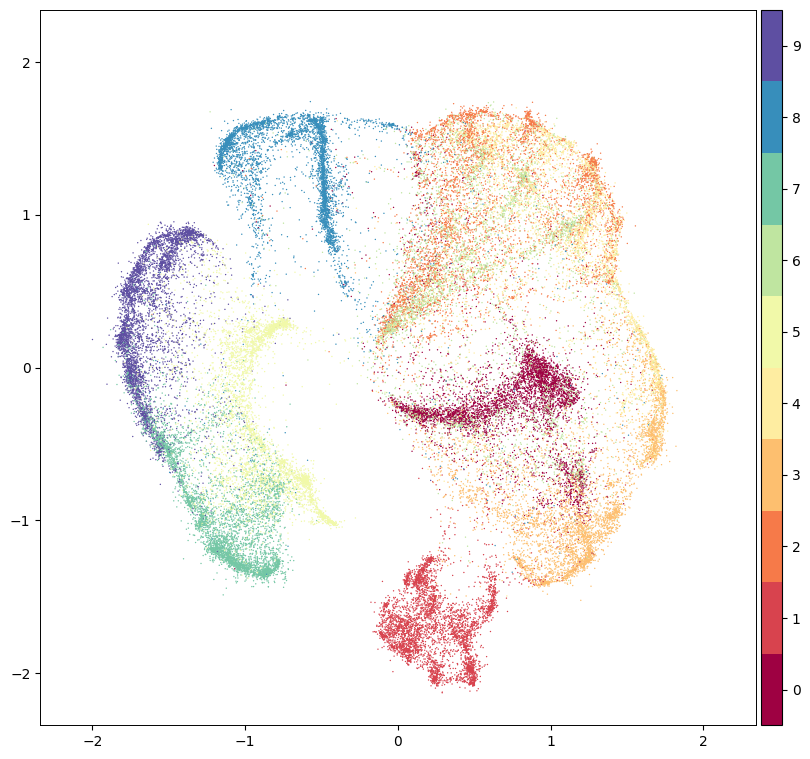

In [16]:
embedding = pymde.preserve_neighbors(train_images_scaled, constraint=pymde.Standardized()).embed(verbose=True)
pymde.plot(embedding, color_by=train_labels)

2. **Centered Constraint**
- **Description**: Ensures that the embedding is centered around the origin (zero mean).
- **Use Case**: Useful when you want the embedding to be centered but not necessarily standardized.
- **Benefits**:
  - **Balanced Data**: Centers the data around the origin.
  - **Simpler Interpretation**: Easier to interpret the relationships between data points.
- **Example**:


Oct 26 03:33:35 PM: Fitting a centered embedding into R^2, for a graph with 48000 items and 1161027 edges.
Oct 26 03:33:35 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:33:35 PM: iteration 000 | distortion 0.313025 | residual norm 0.0289947 | step length 0.445326 | percent change 0.00416736
Oct 26 03:33:38 PM: iteration 030 | distortion 0.122007 | residual norm 0.000467386 | step length 1 | percent change 2.80141
Oct 26 03:33:41 PM: iteration 060 | distortion 0.111837 | residual norm 0.000149223 | step length 1 | percent change 1.33025
Oct 26 03:33:44 PM: iteration 090 | distortion 0.109754 | residual norm 0.000104504 | step length 1 | percent change 0.160987
Oct 26 03:33:47 PM: iteration 120 | distortion 0.108847 | residual norm 0.000101617 | step length 1 | percent change 0.623386
Oct 26 03:33:50 PM: iteration 150 | distortion 0.108351 | residual norm 3.96404e-05 | step length 1 | percent change 0.166762
Oct 26 03:33:53 PM: iteration 180 | distort

<Axes: >

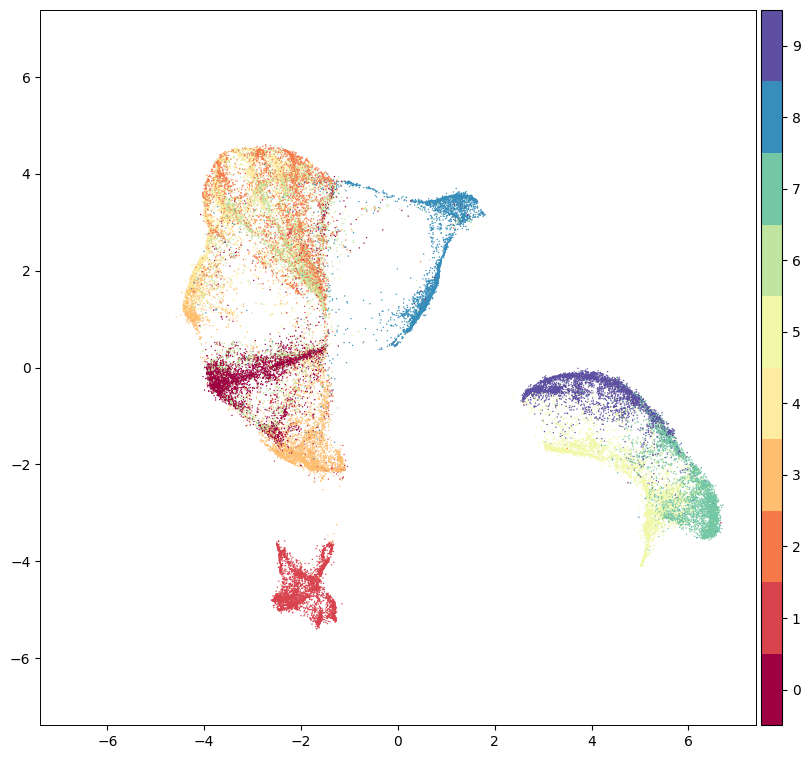

In [14]:
embedding = pymde.preserve_neighbors(train_images_scaled, constraint=pymde.Centered()).embed(verbose=True)
pymde.plot(embedding, color_by=train_labels)

### **Recommendation for Fashion MNIST**
For the Fashion MNIST dataset, the Standardized Constraint is generally the best choice. Here's why:

1. **Consistent Scaling**: Fashion MNIST images are normalized and scaled, so applying a standardized constraint ensures that the embedding maintains this consistency.
2. **Balanced Visualization**: The zero mean ensures that the data is centered, making the visualization more balanced and easier to interpret.
3. **Enhanced Interpretability**: The unit variance ensures that the spread of the data is consistent, making it easier to compare different classes.

### **Without Constraint**
- **Behavior**: The embedding may have arbitrary scaling and mean, making it less interpretable.

Oct 26 03:34:46 PM: Computing 15-nearest neighbors, with max_distance=None
Sat Oct 26 15:34:46 2024 Building RP forest with 20 trees
Sat Oct 26 15:34:48 2024 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	Stopping threshold met -- exiting after 3 iterations
Oct 26 03:34:50 PM: Computing quadratic initialization.
Oct 26 03:35:00 PM: Fitting a centered embedding into R^2, for a graph with 48000 items and 1161001 edges.
Oct 26 03:35:00 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:35:00 PM: iteration 000 | distortion 0.312394 | residual norm 0.0204143 | step length 0.456845 | percent change 0.00301001
Oct 26 03:35:04 PM: iteration 030 | distortion 0.120908 | residual norm 0.000421702 | step length 1 | percent change 1.52523
Oct 26 03:35:07 PM: iteration 060 | distortion 0.110781 | residual norm 0.000190579 | step length 1 | percent change 0.134624
Oct 26 03:35:10 PM: iteration 090 | distortion 0.109194 | residual norm 0.000127331 | step

<Axes: >

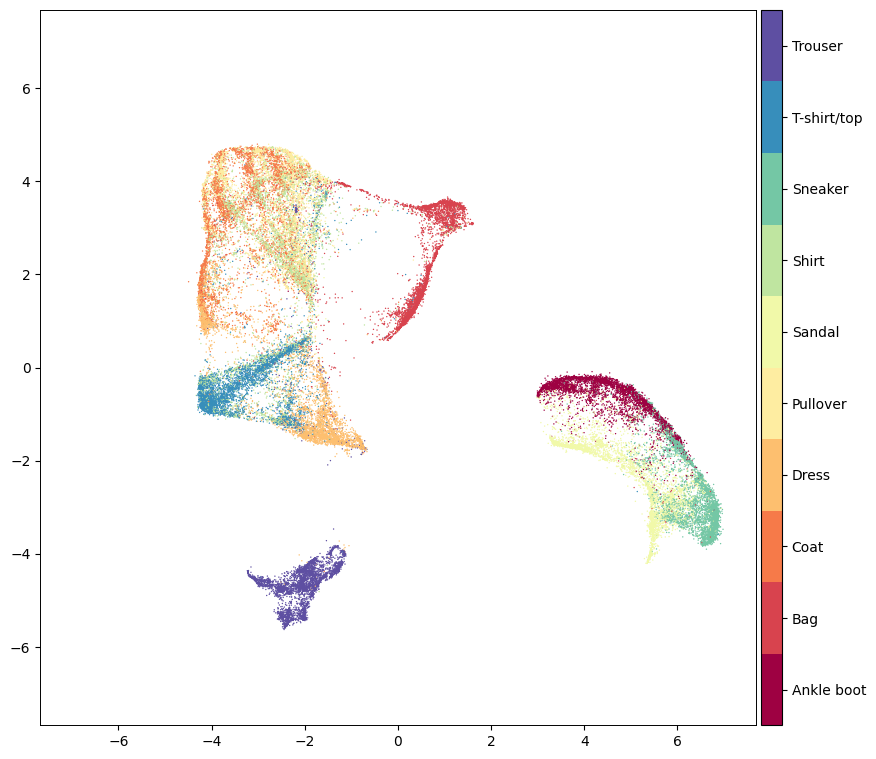

In [15]:
import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PyMDE
embedding = pymde.preserve_neighbors(train_images_scaled, verbose=True).embed(verbose=True)

# Create DataFrame
df = pd.DataFrame(embedding, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
          5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
df["class"].replace(labels, inplace=True)

# Visualize the results with PyMDE's built-in plot function
pymde.plot(embedding, color_by=df["class"])

### **With Standardized Constraint**
- **Behavior**: The embedding will have zero mean and unit variance, making it easier to interpret and compare.

Oct 26 03:31:12 PM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 870856 edges.
Oct 26 03:31:12 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:31:12 PM: iteration 000 | distortion 0.216881 | residual norm 0.0183238 | step length 0.594014 | percent change 0.003513
Oct 26 03:31:15 PM: iteration 030 | distortion 0.136753 | residual norm 0.000333817 | step length 1 | percent change 0.966393
Oct 26 03:31:17 PM: iteration 060 | distortion 0.134229 | residual norm 0.000109821 | step length 1 | percent change 0.383009
Oct 26 03:31:20 PM: iteration 090 | distortion 0.133876 | residual norm 8.02995e-05 | step length 1 | percent change 0.224883
Oct 26 03:31:22 PM: iteration 120 | distortion 0.133584 | residual norm 6.18556e-05 | step length 1 | percent change 0.495814
Oct 26 03:31:25 PM: iteration 150 | distortion 0.133390 | residual norm 6.65233e-05 | step length 1 | percent change 0.50427
Oct 26 03:31:27 PM: iteration 180 | disto

<Axes: >

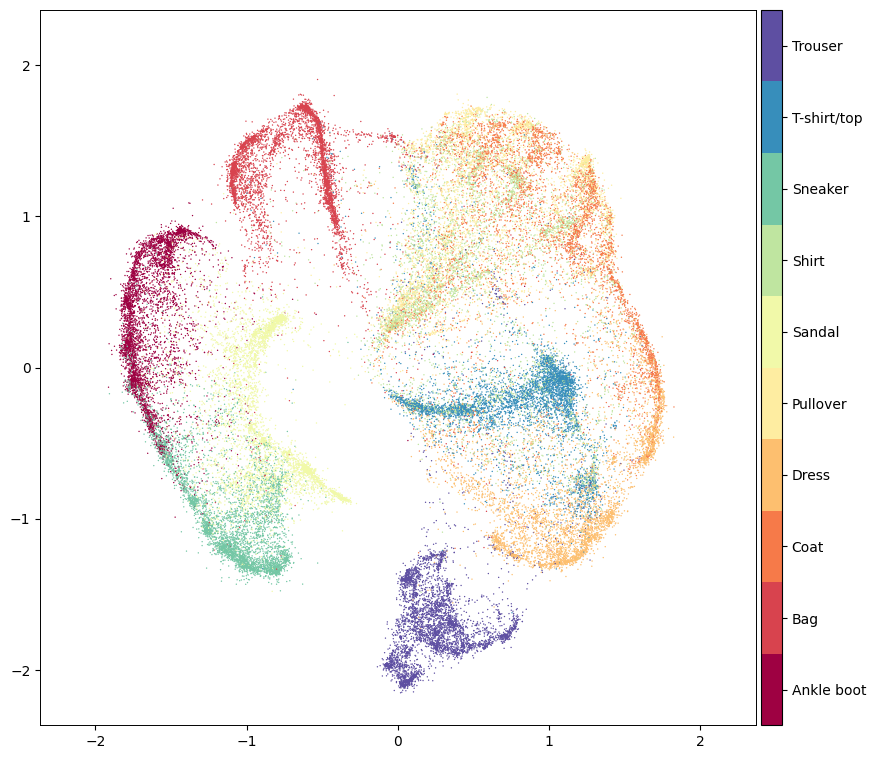

In [12]:
# Standardizes the embedding to have zero mean and unit variance

import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PyMDE with constraint
embedding = pymde.preserve_neighbors(train_images_scaled, constraint=pymde.Standardized()).embed(verbose=True)

# Create DataFrame
df = pd.DataFrame(embedding, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
          5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
df["class"].replace(labels, inplace=True)

# Visualize the results with PyMDE's built-in plot function
pymde.plot(embedding, color_by=df["class"])

### **What are Penalties?**
In PyMDE, penalties are functions that define how the distances between points in the embedding space should be penalized. They influence how the embedding is shaped by controlling the attractive and repulsive forces between points. Penalties help in preserving the structure of the data by minimizing distortion during the dimensionality reduction process.

### **Common Penalties**

1. **Quadratic Penalty**:

- **Description**: Applies a quadratic penalty to the distances between points. This means that the penalty increases quadratically as the distance increases.
- **Use Case**: Useful for preserving local distances and ensuring that similar points remain close to each other.
- **Example**:


In [ ]:
distortion_function = pymde.penalties.Quadratic(weights)

2. **Logarithmic Penalty**:

- **Description**: Applies a logarithmic penalty to the distances between points. This means that the penalty increases logarithmically as the distance increases.
- **Use Case**: Useful for preserving global structure and ensuring that distant points do not get too close.
- **Example**:


In [ ]:
distortion_function = pymde.penalties.Logarithmic(weights)

3. **Exponential Penalty**:

- **Description**: Applies an exponential penalty to the distances between points. This means that the penalty increases exponentially as the distance increases.
- **Use Case**: Useful for emphasizing the separation between distant points.
- **Example**:


In [ ]:
distortion_function = pymde.penalties.Exponential(weights)

 ### **When to Use Penalties?**
- **Quadratic Penalty:** Use when you want to preserve local distances and ensure that similar points remain close to each other. Ideal for datasets where local structure is important.
- **Logarithmic Penalty**: Use when you want to preserve global structure and ensure that distant points do not get too close. Ideal for datasets where global relationships are important.
- **Exponential Penalty**: Use when you want to emphasize the separation between distant points. Ideal for datasets where distinguishing between different clusters is important.

### **How to Use Penalties?**
Penalties are used in the `distortion_function` parameter of the MDE class. You can specify the penalty function and the corresponding weights.

### **Choosing the Right Penalty for Fashion MNIST**
For the Fashion MNIST dataset, the Quadratic Penalty is generally the best choice. Here's why:

1. **Preserve Local Structure**: Fashion MNIST images have local structures that are important to preserve. The quadratic penalty ensures that similar images remain close to each other in the embedding space.
2. **Balanced Distortion**: The quadratic penalty provides a balanced approach to minimizing distortion, making it suitable for datasets with both local and global structures.
3. **Enhanced Interpretability**: By preserving local distances, the quadratic penalty helps in creating embeddings that are easier to interpret and analyze.

### **Quadratic MDE problems**

Oct 26 03:50:25 PM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 542595 edges.
Oct 26 03:50:25 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:50:25 PM: iteration 000 | distortion 20.796509 | residual norm 0.075937 | step length 221.553 | percent change 5.42994
Oct 26 03:50:26 PM: iteration 030 | distortion 0.402445 | residual norm 0.00561676 | step length 1 | percent change 4.33976
Oct 26 03:50:28 PM: iteration 060 | distortion 0.134345 | residual norm 0.00201834 | step length 1 | percent change 2.66531
Oct 26 03:50:29 PM: iteration 090 | distortion 0.069075 | residual norm 0.00155201 | step length 1 | percent change 3.20667
Oct 26 03:50:30 PM: iteration 120 | distortion 0.057249 | residual norm 0.000571467 | step length 1 | percent change 0.437203
Oct 26 03:50:32 PM: iteration 150 | distortion 0.056385 | residual norm 8.94631e-05 | step length 1 | percent change 0.0463507
Oct 26 03:50:33 PM: iteration 180 | distortion 

<Axes: >

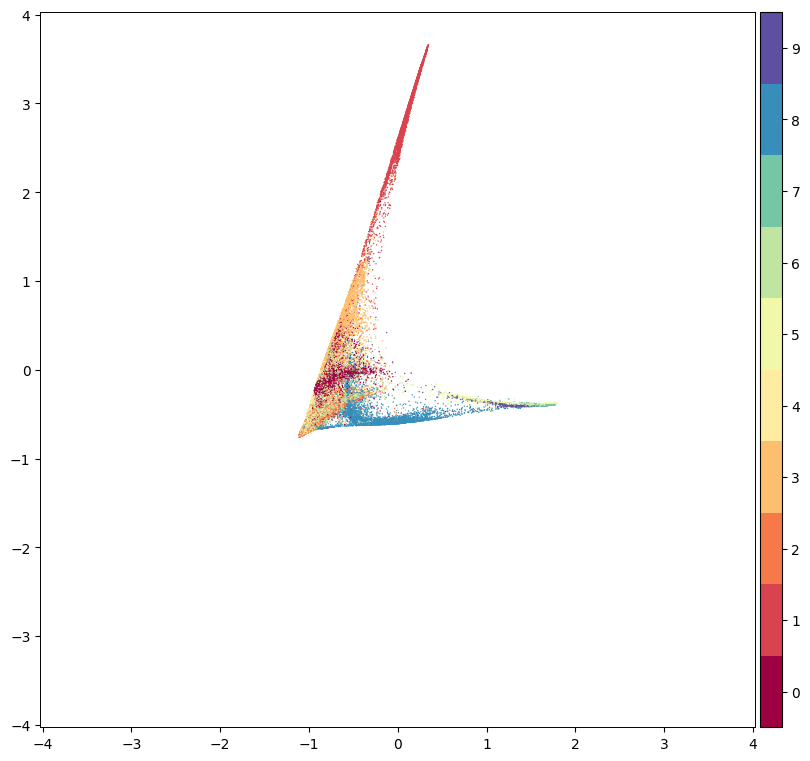

In [17]:
import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pynndescent
import torch

# Assuming train_images_scaled and train_labels are already defined and normalized

# Compute k-nearest neighbors graph using pynndescent
knn_index = pynndescent.NNDescent(train_images_scaled, n_neighbors=15, metric='euclidean')
knn_indices, knn_distances = knn_index.neighbor_graph

# Create edges and weights for the knn_graph
edges = [(i, knn_indices[i, j]) for i in range(knn_indices.shape[0]) for j in range(knn_indices.shape[1])]
edges = torch.tensor(edges, dtype=torch.int64)
weights = torch.tensor(knn_distances.flatten(), dtype=torch.float32)

# Define knn_graph using pymde.Graph.from_edges
knn_graph = pymde.Graph.from_edges(edges, weights)

# Create 2D MDE with Quadratic distortion function and Standardized constraint
quadratic_mde_2d = pymde.MDE(
    n_items=train_images_scaled.shape[0],
    embedding_dim=2,
    edges=knn_graph.edges,
    distortion_function=pymde.penalties.Quadratic(knn_graph.weights),
    constraint=pymde.Standardized()
)

# Embed and plot 2D MDE
quadratic_mde_2d.embed(verbose=True)
quadratic_mde_2d.plot(color_by=train_labels)

Oct 26 03:50:49 PM: Fitting a standardized embedding into R^3, for a graph with 48000 items and 542595 edges.
Oct 26 03:50:49 PM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:50:50 PM: iteration 000 | distortion 31.315615 | residual norm 0.0942501 | step length 981.432 | percent change 24.3759
Oct 26 03:50:51 PM: iteration 030 | distortion 0.892475 | residual norm 0.0174512 | step length 1 | percent change 13.9515
Oct 26 03:50:53 PM: iteration 060 | distortion 0.251479 | residual norm 0.00236517 | step length 1 | percent change 3.99874
Oct 26 03:50:55 PM: iteration 090 | distortion 0.189498 | residual norm 0.00144882 | step length 1 | percent change 3.22204
Oct 26 03:50:56 PM: iteration 120 | distortion 0.155657 | residual norm 0.00108665 | step length 1 | percent change 0.954684
Oct 26 03:50:58 PM: iteration 150 | distortion 0.150941 | residual norm 0.000263603 | step length 1 | percent change 0.141392
Oct 26 03:51:00 PM: iteration 180 | distortion 0.

<Axes3D: >

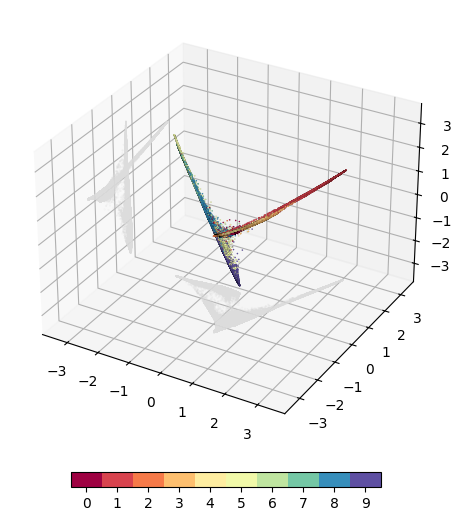

In [18]:
# Create 3D MDE with Quadratic distortion function and Standardized constraint
quadratic_mde_3d = pymde.MDE(
    n_items=train_images_scaled.shape[0],
    embedding_dim=3,
    edges=knn_graph.edges,
    distortion_function=pymde.penalties.Quadratic(knn_graph.weights),
    constraint=pymde.Standardized()
)

# Embed and plot 3D MDE
quadratic_mde_3d.embed(verbose=True)
quadratic_mde_3d.plot(color_by=train_labels)

This code demonstrates how to use PyMDE (Minimum Distortion Embedding) to create 2D and 3D visualizations of the Fashion MNIST dataset. The process involves the following steps:

1. **Compute k-Nearest Neighbors Graph**: Using `pynndescent`, we compute the k-nearest neighbors graph for the scaled training images. This graph captures the local neighborhood structure of the data.

2. **Create Edges and Weights**: We create a list of edges and corresponding weights from the k-nearest neighbors graph. These are then converted to `torch.Tensor` objects, which are required by PyMDE.

3. **Define Graph**: Using `pymde.Graph.from_edges`, we define the graph structure that will be used for the embedding.

4. **Create and Embed MDE**: We create two instances of the `MDE` class:
   - **2D Embedding**: A 2-dimensional embedding with a quadratic distortion function and standardized constraint.
   - **3D Embedding**: A 3-dimensional embedding with the same settings.

5. **Visualize**: We embed the data and visualize the results using PyMDE's built-in plotting functions, coloring the points by their class labels.

### Purpose

- **Preserve Neighborhood Structure**: PyMDE aims to create embeddings that preserve the local neighborhood structure of the data, minimizing distortion.
- **Standardization**: The `Standardized` constraint ensures that the resulting embeddings have zero mean and unit variance, making them more interpretable and consistent.
- **Quadratic Distortion Function**: The quadratic distortion function helps in maintaining the distances between points in the embedding space, ensuring that similar points remain close to each other.

### Why Use This?

- **Dimensionality Reduction**: Reducing the dimensionality of high-dimensional data makes it easier to visualize and analyze.
- **Interpretability**: Standardized embeddings are easier to interpret and compare.
- **Preserve Data Structure**: By preserving the neighborhood structure, PyMDE ensures that the essential relationships in the data are maintained in the lower-dimensional space.

This approach is particularly useful for visualizing complex datasets like Fashion MNIST, where understanding the relationships between different classes can provide valuable insights.

## **Summary**
- **Standardized Constraint**: Ensures zero mean and unit variance, providing consistent scaling and centering.
- **Quadratic Penalty**: Preserves local structure, provides balanced distortion, and enhances interpretability.